• Minggu 1-2 (Inisiasi):

In [1]:
pip install google-play-scraper

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd

# Ambil review Gojek
result, _ = reviews(
    'com.gojek.app',
    lang='id',
    country='id',
    sort=Sort.NEWEST,
    count=2000
)

# Convert ke DataFrame
df = pd.DataFrame(result)

# Ambil kolom penting
df = df[['content', 'score']]

# Rename
df.columns = ['text', 'rating']

# Simpan RAW DATA
df.to_csv("data_raw_gojek.csv", index=False)

print(df.head())
print("Jumlah data:", len(df))

                                                text  rating
0  Ampun deh, pesen gojek dr tadi nganter sama je...       1
1                                     so far so good       5
2                               driver nya ok.ramah👍       5
3                                oke sangat membantu       5
4                                           goodluck       5
Jumlah data: 2000


In [3]:
import os

# buat folder data/raw
os.makedirs("data/raw", exist_ok=True)

print("Folder berhasil dibuat!")

Folder berhasil dibuat!


In [4]:
df.to_csv("data/raw/data_raw_gojek.csv", index=False)

print("File berhasil disimpan!")

File berhasil disimpan!


In [5]:
# from google.colab import files

# files.download("data/raw/data_raw_gojek.csv")

• Minggu 3-4 (Data Profiling)

In [6]:
print(df.isnull().sum())

text      0
rating    0
dtype: int64


In [7]:
print("Jumlah duplikat:", df.duplicated().sum())

Jumlah duplikat: 387


In [8]:
df['length'] = df['text'].astype(str).apply(len)

print(df['length'].describe())

count    2000.000000
mean       64.906500
std        92.188639
min         1.000000
25%         9.000000
50%        26.000000
75%        79.000000
max       500.000000
Name: length, dtype: float64


In [9]:
df.sample(10)

,text,rating,length
180,pokok e mantap menggunakan aplikasi gojek,5,41
1825,sejauh ini saya pakai gojek sangat baik... dri...,5,94
1625,kuli bangunan,5,13
265,mantap semoga lebih baik lagi,5,29
901,perjalanan jadi lebih aman dan nyaman,5,37
1683,mantap,5,6
1956,"besstt... sukses terus, ttp jadi andalan semua...",5,53
296,Aplikasi terbaru dg biaya aplikasi 3rb rupiah ...,4,111
568,lebih detail dripada apk sebelah,4,32
443,"ikan lele bentuknya jelek, i love u gojek 😦😦",5,44


In [10]:
from collections import Counter

all_text = " ".join(df['text'].astype(str)).lower()
words = all_text.split()

word_counts = Counter(words)

print(word_counts.most_common(20))

[('di', 383), ('driver', 363), ('dan', 315), ('saya', 298), ('gojek', 239), ('sangat', 230), ('aplikasi', 218), ('yg', 207), ('nya', 192), ('tidak', 190), ('yang', 185), ('ga', 167), ('bisa', 163), ('bagus', 159), ('ada', 158), ('gak', 150), ('mau', 148), ('membantu', 132), ('ini', 131), ('tapi', 113)]


In [11]:
!pip install wordcloud matplotlib

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


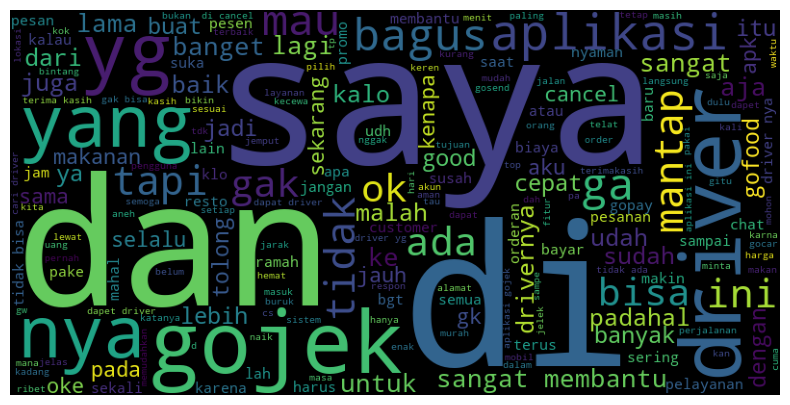

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

wordcloud = WordCloud(width=800, height=400).generate(all_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

• Minggu 5-6 (Basic Cleaning):

In [13]:
#CASE FOLDING
df['text'] = df['text'].astype(str).str.lower()

In [14]:
#REGEX CLEANING
import re

def clean_text(text):
    text = re.sub(r'http\S+', '', text)       # hapus URL
    text = re.sub(r'@\w+', '', text)          # hapus mention
    text = re.sub(r'#\w+', '', text)          # hapus hashtag
    text = re.sub(r'\d+', '', text)           # hapus angka
    text = re.sub(r'[^a-zA-Z\s]', '', text)   # hapus simbol & emoji
    text = re.sub(r'\s+', ' ', text).strip()  # hapus spasi berlebih
    return text

df['clean_text'] = df['text'].apply(clean_text)

In [15]:
#FILTERING
# hapus teks yang terlalu pendek (< 3 kata)
df['word_count'] = df['clean_text'].apply(lambda x: len(x.split()))

df_filtered = df[df['word_count'] >= 3]

print("Sebelum filtering:", len(df))
print("Sesudah filtering:", len(df_filtered))

Sebelum filtering: 2000
Sesudah filtering: 1236


In [16]:
import os

os.makedirs("data/processed", exist_ok=True)

df_filtered.to_csv("data/processed/data_clean_gojek.csv", index=False)

• Minggu 7-8 (Advanced Normalization)

In [17]:
import pandas as pd

df = pd.read_csv("data/processed/data_clean_gojek.csv")
df.head()

,text,rating,length,clean_text,word_count
0,"ampun deh, pesen gojek dr tadi nganter sama je...",1,68,ampun deh pesen gojek dr tadi nganter sama jem...,11
1,so far so good,5,14,so far so good,4
2,driver nya ok.ramah👍,5,20,driver nya okramah,3
3,oke sangat membantu,5,19,oke sangat membantu,3
4,saya menyaygkan keputusan sepihak terkait peng...,1,500,saya menyaygkan keputusan sepihak terkait peng...,69


In [18]:
slang_dict = {
    "bgt": "banget",
    "bgtt": "banget",
    "gk": "tidak",
    "ga": "tidak",
    "nggak": "tidak",
    "tdk": "tidak",
    "mantul": "mantap betul",
    "oke": "baik",
    "ok": "baik",
    "dr": "dari",
    "tp": "tapi",
    "aja": "saja",
    "udh": "sudah",
    "blm": "belum",
    "lg": "lagi",
    "krn": "karena",
    "dgn": "dengan"
}

In [19]:
#NORMALISASI TEKS
def normalize_text(text):
    words = text.split()
    normalized = [slang_dict[word] if word in slang_dict else word for word in words]
    return " ".join(normalized)

df['normalized_text'] = df['clean_text'].apply(normalize_text)

In [20]:
df[['clean_text', 'normalized_text']].head(10)

,clean_text,normalized_text
0,ampun deh pesen gojek dr tadi nganter sama jem...,ampun deh pesen gojek dari tadi nganter sama j...
1,so far so good,so far so good
2,driver nya okramah,driver nya okramah
3,oke sangat membantu,baik sangat membantu
4,saya menyaygkan keputusan sepihak terkait peng...,saya menyaygkan keputusan sepihak terkait peng...
5,praktis di saat kritis,praktis di saat kritis
6,driver sangat berhati dalam membawa penumpangt...,driver sangat berhati dalam membawa penumpangt...
7,sangat membantu dlm perjalanan,sangat membantu dlm perjalanan
8,bintang aja dulu ruwet kek co nya gk jelas,bintang saja dulu ruwet kek co nya tidak jelas
9,bagaimana ya dengan aplikasi ini apakah tidak ...,bagaimana ya dengan aplikasi ini apakah tidak ...


In [21]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\wongp\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [22]:
#TOKENIZING
from nltk.tokenize import word_tokenize

df['tokens'] = df['normalized_text'].apply(word_tokenize)

In [23]:
!pip install google-play-scraper Sastrawi nltk

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
#STOPWORD REMOVAL
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory

factory = StopWordRemoverFactory()
stopwords = set(factory.get_stop_words())

df['tokens'] = df['tokens'].apply(lambda x: [word for word in x if word not in stopwords])

In [25]:
#STEMPING
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

stemmer = StemmerFactory().create_stemmer()

df['tokens'] = df['tokens'].apply(lambda x: [stemmer.stem(word) for word in x])

In [26]:
df['final_text'] = df['tokens'].apply(lambda x: " ".join(x))

In [27]:
import os

os.makedirs("data/processed", exist_ok=True)

df.to_csv("data/processed/data_final_gojek.csv", index=False)

print("Advanced normalization selesai!")

Advanced normalization selesai!


In [28]:
# from google.colab import drive
# drive.mount('/content/drive')

In [29]:
# df.to_csv('/content/drive/MyDrive/data_final_gojek.csv', index=False)

In [30]:
df[['text', 'final_text']].sample(10)

,text,final_text
655,pd hari snin sktr jam stngah enam saya di ancm...,pd hari snin sktr jam stngah enam ancm mw mtik...
65,"go food nya jelek, nggak bisa cancel padahal r...",go food nya jelek cancel padahal restoran nya ...
596,ngebantu bgt terus banyak diskin lop lop deh,ngebantu banget terus banyak diskin lop lop deh
312,"jujur baru sekarang kecewa sama driver gocar, ...",jujur baru sekarang kecewa sama driver gocar k...
336,sopirnya enak ramah & sabar,sopir enak ramah sabar
151,tidak bisa memesan apapun di tolak,mes apa tolak
411,pajak 25% sangat lah besar kasian para driver ...,pajak sangat lah besar kasi driver yg pke moto...
1159,"sangat baik, harga terjangkau buat mahasiswa",sangat baik harga jangkau buat mahasiswa
856,biaya aplikasi besar mitra dan customer semaki...,biaya aplikasi besar mitra customer makin tindas
872,fitur kirim gambar ga segera diadakan. semakin...,fitur kirim gambar segera ada makin ribet kalo...


In [31]:
df[['text', 'clean_text', 'normalized_text', 'final_text']].sample(10)

,text,clean_text,normalized_text,final_text
1067,permainan baloknya kek nipu. soalnya pas skor ...,permainan baloknya kek nipu soalnya pas skor u...,permainan baloknya kek nipu soalnya pas skor u...,main balok kek nipu soal pas skor udah kata sk...
463,suka bangett pke apk ini dn gojekk nii penyela...,suka bangett pke apk ini dn gojekk nii penyela...,suka bangett pke apk ini dn gojekk nii penyela...,suka bangett pke apk dn gojekk nii selamat kuu
945,"para driver gojek itu keren keren banget, pada...",para driver gojek itu keren keren banget pada ...,para driver gojek itu keren keren banget pada ...,driver gojek keren keren banget ramah orang or...
165,"gojek semakin buruk ,banyak driver yang tidak ...",gojek semakin buruk banyak driver yang tidak m...,gojek semakin buruk banyak driver yang tidak m...,gojek makin buruk banyak driver merespon bahka...
871,driver nya malas,driver nya malas,driver nya malas,driver nya malas
614,"pesan gofood,sampai satu setengah jam gak dapa...",pesan gofoodsampai satu setengah jam gak dapat...,pesan gofoodsampai satu setengah jam gak dapat...,pesan gofoodsampai satu tengah jam gak driverk...
840,mahal kali harga di apk daripada tokonya langs...,mahal kali harga di apk daripada tokonya langs...,mahal kali harga di apk daripada tokonya langs...,mahal kali harga apk toko langsung masa iya be...
44,mau bikin akun malah nomor telponnya udah dipa...,mau bikin akun malah nomor telponnya udah dipa...,mau bikin akun malah nomor telponnya udah dipa...,mau bikin akun malah nomor telpon udah dipake ...
834,gojek paylater bekerja sama dengan pinjol find...,gojek paylater bekerja sama dengan pinjol find...,gojek paylater bekerja sama dengan pinjol find...,gojek paylater kerja sama pinjol findaya kerja...
791,drivernya gk amanah!! banyak bikin kecewa!,drivernya gk amanah banyak bikin kecewa,drivernya tidak amanah banyak bikin kecewa,drivernya amanah banyak bikin kecewa


In [32]:
df[['text', 'final_text']].sample(5)

,text,final_text
889,mantap sangat cocok aman dan harga bersahabat,mantap sangat cocok aman harga sahabat
934,"susah cari driver, banyak kendaraan driver yan...",susah cari driver banyak kendara driver layak ...
353,lebih cepat jemput,lebih cepat jemput
1003,"keren dan baik abang nya ,, terimakasih gojek ...",keren baik abang nya terimakasih gojek
667,promonya mantan dn cepat,promonya mantan dn cepat


• Minggu 9-10 (Domain-Specific Labeling)

In [33]:
#LABELING
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['label'] = df['rating'].apply(label_sentiment)

df[['rating', 'label']].head()

,rating,label
0,1,negatif
1,5,positif
2,5,positif
3,5,positif
4,1,negatif


In [34]:
df['label'].value_counts()

label
positif    656
negatif    520
netral      60
Name: count, dtype: int64

In [35]:
(df['label'].value_counts(normalize=True) * 100).round(2)

label
positif    53.07
negatif    42.07
netral      4.85
Name: proportion, dtype: float64

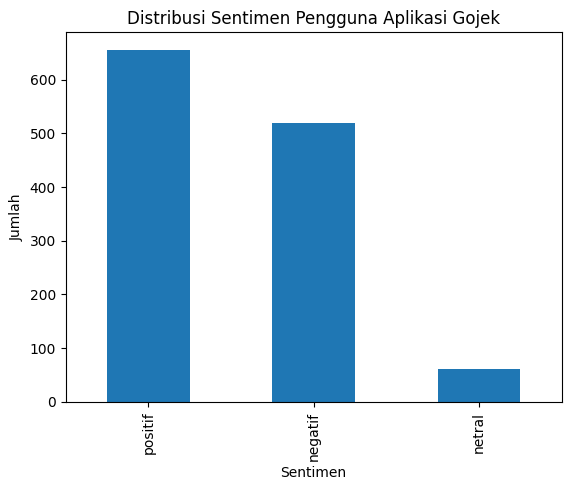

In [36]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar')
plt.title("Distribusi Sentimen Pengguna Aplikasi Gojek")
plt.xlabel("Sentimen")
plt.ylabel("Jumlah")
plt.show()

In [37]:
df.groupby('label')['rating'].mean()

label
negatif    1.121154
netral     3.000000
positif    4.891768
Name: rating, dtype: float64

In [38]:
df['label'].value_counts()

label
positif    656
negatif    520
netral      60
Name: count, dtype: int64

• Minggu 11-12 (Validation & Documentation)

In [39]:
df_sample = df.sample(100)
df_sample[['text', 'final_text']].head(10)

,text,final_text
528,lebih mudah prak tis dan layanan yg bagus,lebih mudah prak tis layan yg bagus
952,"ga bgt, drivernya susah di cari",banget drivernya susah cari
103,pokok e mantap menggunakan aplikasi gojek,pokok e mantap guna aplikasi gojek
752,perjalanan yg menyenangkan dan nyaman,jalan yg senang nyaman
405,"good job, dan menyenangkan.",good job senang
781,apk yg membantu bangat,apk yg bantu bangat
110,apk tai ajg gblg,apk tai ajg gblg
630,sekarang kalo salah pesen baru pesen gk bisa d...,sekarang kalo salah sen baru sen cancel rubah ...
1151,aplikasi nya ngebug ga ada tanda kirim file ja...,aplikasi nya ngebug tanda kirim file jadi kiri...
490,moda transportasi yang nyaman dan terbaikku,moda transportasi nyaman baik


In [40]:
df.groupby('label')['rating'].mean()

label
negatif    1.121154
netral     3.000000
positif    4.891768
Name: rating, dtype: float64

In [41]:
df.sample(10)[['text','final_text']]

,text,final_text
890,oke cm diskon voucher susah,baik cm diskon voucher susah
463,suka bangett pke apk ini dn gojekk nii penyela...,suka bangett pke apk dn gojekk nii selamat kuu
1032,sangat mudah dan terpercaya,sangat mudah percaya
336,sopirnya enak ramah & sabar,sopir enak ramah sabar
63,driver min atitude maen nylonong masuk aja tolol,driver min atitude maen nylonong masuk tolol
981,"mudah, murah, cepat, aman.",mudah murah cepat aman
1158,"tadi msih ada gangguan sinyal, meski bagus",tadi msih ganggu sinyal meski bagus
174,"kocak bikin ga enak aja, udah selesai sampe tu...",kocak bikin enak udah selesai sampe tuju tiba ...
621,udah seminggu padahal transaksi batal tapi sal...,udah minggu padahal transaksi batal saldo poto...
47,gojek sangat membantu saya untuk aktivitas har...,gojek sangat bantu aktivitas hari antar jemput...


• MODELING + EVALUASI (LOGISTIC REGRESSION)

In [42]:
import pandas as pd

df = pd.read_csv("data/processed/data_final_gojek.csv")

df.head()

,text,rating,length,clean_text,word_count,normalized_text,tokens,final_text
0,"ampun deh, pesen gojek dr tadi nganter sama je...",1,68,ampun deh pesen gojek dr tadi nganter sama jem...,11,ampun deh pesen gojek dari tadi nganter sama j...,"['ampun', 'deh', 'sen', 'gojek', 'tadi', 'ngan...",ampun deh sen gojek tadi nganter sama jemput j...
1,so far so good,5,14,so far so good,4,so far so good,"['so', 'far', 'so', 'good']",so far so good
2,driver nya ok.ramah👍,5,20,driver nya okramah,3,driver nya okramah,"['driver', 'nya', 'okramah']",driver nya okramah
3,oke sangat membantu,5,19,oke sangat membantu,3,baik sangat membantu,"['baik', 'sangat', 'bantu']",baik sangat bantu
4,saya menyaygkan keputusan sepihak terkait peng...,1,500,saya menyaygkan keputusan sepihak terkait peng...,69,saya menyaygkan keputusan sepihak terkait peng...,"['menyaygkan', 'putus', 'pihak', 'kait', 'hapu...",menyaygkan putus pihak kait hapus voucher prom...


In [43]:
def label_sentiment(score):
    if score >= 4:
        return 'positif'
    elif score == 3:
        return 'netral'
    else:
        return 'negatif'

df['label'] = df['rating'].apply(label_sentiment)

In [44]:
df['label'].value_counts()

label
positif    656
negatif    520
netral      60
Name: count, dtype: int64

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

X = df['final_text'].fillna('')
y = df['label']

tfidf = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf.fit_transform(X)

print(X_tfidf.shape)

(1236, 2849)


In [46]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape)
print("Test :", X_test.shape)

Train: (988, 2849)
Test : (248, 2849)


In [47]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')

model.fit(X_train, y_train)

print("Training selesai!")

Training selesai!


In [48]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['positif' 'negatif' 'negatif' 'negatif' 'negatif' 'positif' 'positif'
 'positif' 'negatif' 'negatif']


In [49]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 78.63%


In [50]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

     negatif       0.75      0.80      0.77       108
      netral       0.00      0.00      0.00        14
     positif       0.81      0.87      0.84       126

    accuracy                           0.79       248
   macro avg       0.52      0.55      0.54       248
weighted avg       0.74      0.79      0.76       248



C:\Users\wongp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\wongp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\wongp\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

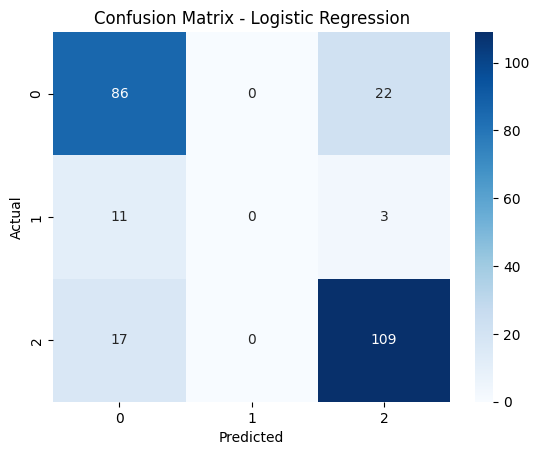

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### ANALISIS TAMBAHAN LOGISTIC REGRESSION

In [52]:
from sklearn.metrics import roc_auc_score, roc_curve
import numpy as np

# Encode label untuk ROC curve (one-vs-rest)
from sklearn.preprocessing import LabelBinarizer

lb = LabelBinarizer()
y_test_bin = lb.fit_transform(y_test)
y_pred_proba = model.predict_proba(X_test)

# Hitung ROC AUC untuk setiap kelas
roc_auc = roc_auc_score(y_test_bin, y_pred_proba, multi_class='ovr', average='weighted')
print(f"Weighted ROC AUC Score: {roc_auc:.4f}")

Weighted ROC AUC Score: 0.8735


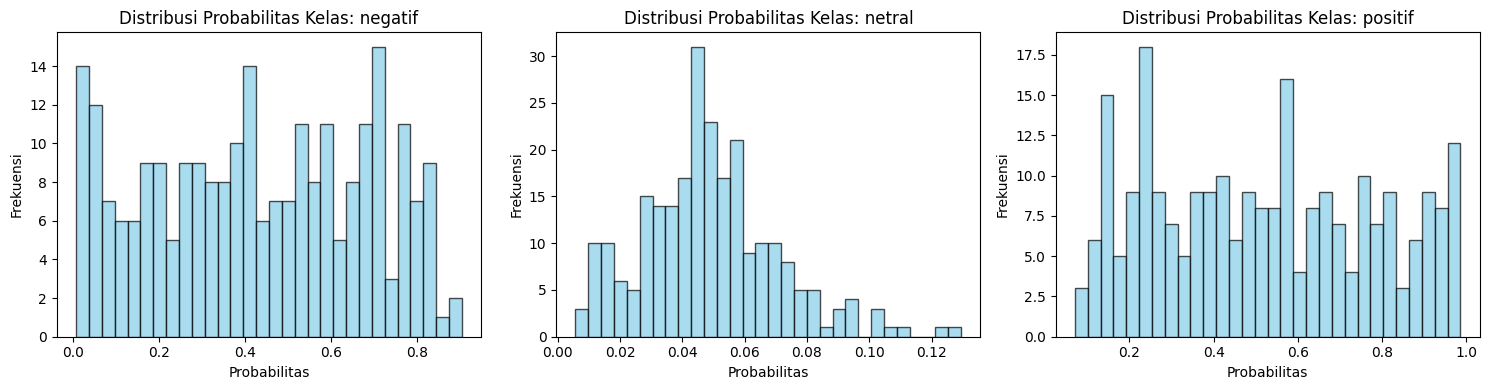

In [53]:
# Visualisasi probabilitas prediksi
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

class_names = model.classes_
for i, class_name in enumerate(class_names):
    axes[i].hist(y_pred_proba[:, i], bins=30, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribusi Probabilitas Kelas: {class_name}')
    axes[i].set_xlabel('Probabilitas')
    axes[i].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

In [54]:
# Feature importance (koefisien model)
feature_names = tfidf.get_feature_names_out()
coefficients = model.coef_

# Ambil top features untuk setiap kelas
for i, class_name in enumerate(model.classes_):
    top_indices = np.argsort(np.abs(coefficients[i]))[-10:]
    top_features = feature_names[top_indices]
    top_coef = coefficients[i][top_indices]
    
    print(f"\nTop 10 Features untuk kelas '{class_name}':")
    for feat, coef in zip(top_features, top_coef):
        print(f"  {feat}: {coef:.4f}")


Top 10 Features untuk kelas 'negatif':
  mantap: -1.0521
  driver: 1.0649
  ramah: -1.1009
  baik: -1.1499
  mudah: -1.1986
  bagus: -1.2088
  sangat: -1.2362
  gak: 1.2615
  udah: 1.2959
  cepat: -1.3569

Top 10 Features untuk kelas 'netral':
  mapsnya: 0.6184
  wilayah: 0.6298
  padahal: 0.6345
  pesan: 0.6391
  makin: 0.6514
  gerak: 0.6557
  terlalu: 0.6749
  kadang: 0.7392
  posisi: 0.8270
  jauh: 1.0811

Top 10 Features untuk kelas 'positif':
  nyaman: 1.1535
  susah: -1.1874
  padahal: -1.2409
  mantap: 1.2838
  ramah: 1.4034
  bantu: 1.4362
  driver: -1.5111
  baik: 1.5151
  mudah: 1.5660
  cepat: 1.7964


In [55]:
# Test dengan contoh teks baru
test_texts = [
    "aplikasi sangat membantu dan mudah digunakan",
    "aplikasi ini jelek dan sering error",
    "biasa saja tidak buruk tidak bagus"
]

test_tfidf = tfidf.transform(test_texts)
predictions = model.predict(test_tfidf)
probabilities = model.predict_proba(test_tfidf)

print("\nPrediksi Sentimen Teks Baru:")
print("="*70)

for text, pred, probs in zip(test_texts, predictions, probabilities):
    print(f"Teks: {text}")
    print(f"Prediksi: {pred}")
    print(f"Confidence:")
    for class_name, prob in zip(model.classes_, probs):
        print(f"  {class_name}: {prob:.4f}")
    print("-"*70)


Prediksi Sentimen Teks Baru:
Teks: aplikasi sangat membantu dan mudah digunakan
Prediksi: positif
Confidence:
  negatif: 0.0425
  netral: 0.0157
  positif: 0.9418
----------------------------------------------------------------------
Teks: aplikasi ini jelek dan sering error
Prediksi: negatif
Confidence:
  negatif: 0.6878
  netral: 0.0355
  positif: 0.2768
----------------------------------------------------------------------
Teks: biasa saja tidak buruk tidak bagus
Prediksi: positif
Confidence:
  negatif: 0.3223
  netral: 0.0474
  positif: 0.6303
----------------------------------------------------------------------
